In [1]:
# 1. Clone dự án từ GitHub
!git clone https://github.com/aniass/Waste-Classification.git
%cd Waste-Classification

# 2. Cài đặt các thư viện cần thiết
!pip install tensorflow numpy matplotlib pillow

Cloning into 'Waste-Classification'...
remote: Enumerating objects: 55, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 55 (delta 30), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (55/55), 1.18 MiB | 4.73 MiB/s, done.
Resolving deltas: 100% (30/30), done.
/content/Waste-Classification


In [2]:
# pip install torchinfo
!pip install torchinfo
import torchvision.models as models
from torchinfo import summary

model = models.resnet18()

# summary(model, input_size=(batch_size, channels, H, W))
model_stats = summary(model, input_size=(1, 3, 224, 224), verbose=0)
print(model_stats)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1000]                 --
├─Conv2d: 1-1                            [1, 64, 112, 112]         9,408
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         128
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           128
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]           --
│

In [3]:
import os

# 1. Thiết lập biến môi trường (Đảm bảo không có dấu cách thừa)
os.environ['KAGGLE_USERNAME'] = "nghiahk2005" # Thay bằng username của bạn
os.environ['KAGGLE_KEY'] = "2825d71d4396d7203aae145eb3a7f509"

# 2. Xử lý lỗi Latin-1 bằng cách cấu hình hệ thống ưu tiên UTF-8
import sys
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding

# 3. Tải dataset và ép buộc ghi đè nếu đã tồn tại
!pip install -q kaggle
!kaggle datasets download -d techsash/waste-classification-data --force

# 4. Kiểm tra xem file đã tải về chưa trước khi unzip
if os.path.exists('waste-classification-data.zip'):
    print("--- Đã tìm thấy file zip. Đang tiến hành giải nén... ---")
    !unzip -q waste-classification-data.zip -d dataset_rac
    print("--- Giải nén thành công! ---")
else:
    print("--- Lỗi: Vẫn chưa tải được file từ Kaggle. Kiểm tra lại Username/Key! ---")

Dataset URL: https://www.kaggle.com/datasets/techsash/waste-classification-data
License(s): CC-BY-SA-4.0
100% 427M/427M [00:06<00:00, 65.4MB/s]

--- Đã tìm thấy file zip. Đang tiến hành giải nén... ---
--- Giải nén thành công! ---


In [4]:
import json
import os

notebook_path = 'Waste_cnn.ipynb'

if os.path.exists(notebook_path):
    with open(notebook_path, 'r', encoding='utf-8') as f:
        waste_cnn_notebook_content = json.load(f)
    print(f"Successfully loaded {notebook_path}")
else:
    print(f"Error: {notebook_path} not found in the current directory ({os.getcwd()}).")
    waste_cnn_notebook_content = None


Successfully loaded Waste_cnn.ipynb


You can use this `predict_image` function to predict new images by replacing `image_path` with the actual path to your new image.

In [5]:
# Imports from Waste_cnn.ipynb (with fix for ImageDataGenerator)
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
# ImageDataGenerator is deprecated in Keras 3, using tf.keras.utils.image_dataset_from_directory instead
import numpy as np
import matplotlib.pyplot as plt
import os

In [6]:
# 1. Khởi tạo dữ liệu và Augmentation (Updated from Waste_cnn.ipynb)
TRAINING_DIR = "dataset_rac/DATASET/TRAIN"
VALIDATION_DIR = "dataset_rac/DATASET/TEST"
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 128

# Define data augmentation layers (will be applied to training data)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
], name="data_augmentation")

# Define rescaling layer (for normalization, applied to both train and validation)
rescaling_layer = tf.keras.layers.Rescaling(1./255)

# Load training dataset using image_dataset_from_directory
train_dataset_raw = tf.keras.utils.image_dataset_from_directory(
    TRAINING_DIR,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Load validation dataset using image_dataset_from_directory
validation_dataset_raw = tf.keras.utils.image_dataset_from_directory(
    VALIDATION_DIR,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Get class names from the raw training dataset (before map/prefetch)
class_names = train_dataset_raw.class_names

# Apply data augmentation and rescaling to the training dataset
def preprocess_train(image, label):
    image = data_augmentation(image)
    image = rescaling_layer(image)
    return image, label

# Apply only rescaling to the validation dataset (no augmentation)
def preprocess_val(image, label):
    image = rescaling_layer(image)
    return image, label

train_dataset = train_dataset_raw.map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
validation_dataset = validation_dataset_raw.map(preprocess_val, num_parallel_calls=tf.data.AUTOTUNE)

# Prefetch for optimal performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

# Print information about the loaded datasets
print(f"Found {tf.data.experimental.cardinality(train_dataset).numpy() * BATCH_SIZE} training images belonging to 2 classes.")
print(f"Found {tf.data.experimental.cardinality(validation_dataset).numpy() * BATCH_SIZE} validation images belonging to 2 classes.")

Found 22564 files belonging to 2 classes.
Found 2513 files belonging to 2 classes.
Found 22656 training images belonging to 2 classes.
Found 2560 validation images belonging to 2 classes.


In [7]:
# 2. Xây dựng mô hình CNN (From Waste_cnn.ipynb)
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dropout(0.5), # Thêm Dropout để chống overfitting
    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 3. Compile mô hình (From Waste_cnn.ipynb)
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [9]:
# 4. Huấn luyện mô hình (Updated from Waste_cnn.ipynb)
NUM_EPOCHS = 20
history = model.fit(
    train_dataset,
    epochs=NUM_EPOCHS,
    validation_data=validation_dataset,
    verbose=1
)

Epoch 1/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 169s 847ms/step - accuracy: 0.7876 - loss: 0.4673 - val_accuracy: 0.8213 - val_loss: 0.3952
Epoch 2/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 177s 787ms/step - accuracy: 0.8175 - loss: 0.4179 - val_accuracy: 0.8285 - val_loss: 0.3783
Epoch 3/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 138s 776ms/step - accuracy: 0.8288 - loss: 0.3920 - val_accuracy: 0.8631 - val_loss: 0.3471
Epoch 4/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 140s 782ms/step - accuracy: 0.8374 - loss: 0.3803 - val_accuracy: 0.8520 - val_loss: 0.3544
Epoch 5/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 143s 791ms/step - accuracy: 0.8401 - loss: 0.3724 - val_accuracy: 0.7827 - val_loss: 0.4944
Epoch 6/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 142s 799ms/step - accuracy: 0.8440 - loss: 0.3654 - val_accuracy: 0.8627 - val_loss: 0.3268
Epoch 7/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 141s 792ms/step - accuracy: 0.8465 - loss: 0.3588 - val_accuracy: 0.8858 - val_loss: 0.2942
Epoch 8/20
177/177 ━━━━━━━━━━━━━━━━━━━━ 139s 782ms/step - accuracy: 0.8538 -

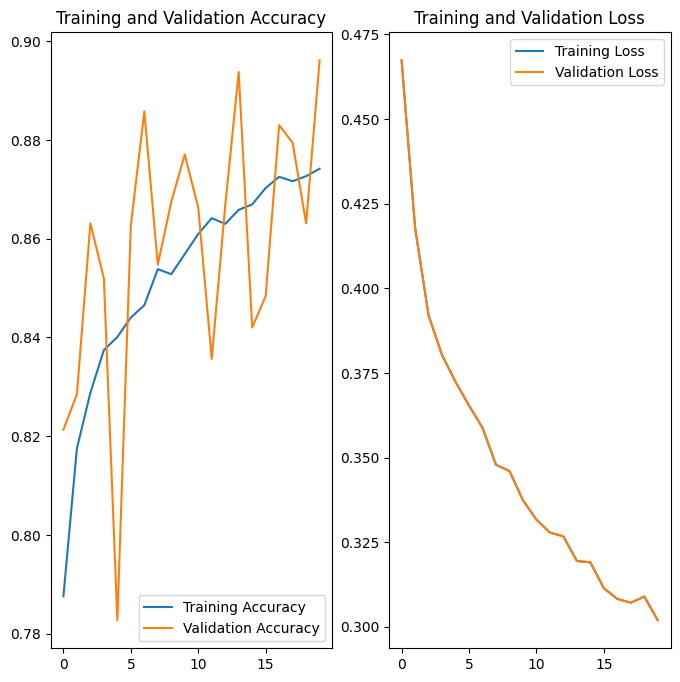

In [10]:
# 5. Đánh giá mô hình (From Waste_cnn.ipynb)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['loss']

epochs_range = range(NUM_EPOCHS)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [11]:
# 6. Lưu mô hình (From Waste_cnn.ipynb)
model_save_path = "./waste_cnn_model.keras"
model.save(model_save_path)
print(f"Mô hình đã được lưu tại: {model_save_path}")

Mô hình đã được lưu tại: ./waste_cnn_model.keras


In [12]:
# 7. Tải và kiểm tra lại mô hình (From Waste_cnn.ipynb)
loaded_model = keras.models.load_model(model_save_path)
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,359,365 (39.52 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,906,244 (26.35 MB)

You can use this `predict_image` function to predict new images by replacing `image_path` with the actual path to your new image.

Predicting for sample image: dataset_rac/DATASET/TEST/O/O_13333.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 765ms/step


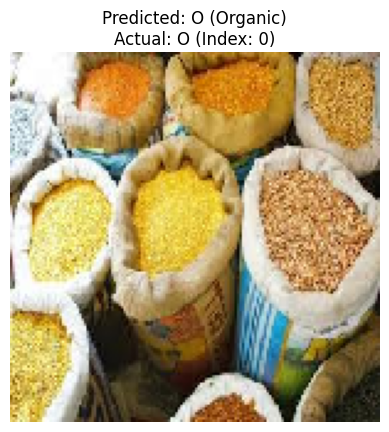

Predicted class for O_13333.jpg: O (Organic)
Actual class for O_13333.jpg: O (Index: 0)


In [13]:
# Predict image function and example usage (Updated from Waste_cnn.ipynb)
def predict_image(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Normalize the image to [0, 1] as done in the training pipeline

    prediction = loaded_model.predict(img_array)

    if prediction[0][0] > 0.5:
        return "R (Recycle)"
    else:
        return "O (Organic)"

# Example usage:
# To properly demonstrate, we need a path to a RAW image.
# Let's find a sample image directly from the validation directory for demonstration.

# Get a class name to pick a sample image from
class_names_list = sorted(os.listdir(VALIDATION_DIR))
if not class_names_list:
    print(f"Error: No class directories found in {VALIDATION_DIR}")
    raw_demo_image_path = None
else:
    sample_class_dir = os.path.join(VALIDATION_DIR, class_names_list[0]) # e.g., 'R'
    sample_image_files = os.listdir(sample_class_dir)

    if sample_image_files:
        raw_demo_image_path = os.path.join(sample_class_dir, sample_image_files[0])
        # The actual true label for this raw_demo_image_path depends on its directory.
        # We can now use the 'class_names' variable directly.
        # Determine the true class based on the directory name from class_names_list
        true_class_for_raw_demo = class_names[0] if class_names_list[0] == class_names[0] else class_names[1]
        true_class_for_raw_demo = f"{true_class_for_raw_demo} (Index: {class_names.index(class_names_list[0])})"

    else:
        raw_demo_image_path = None
        print(f"Could not find any sample images in {sample_class_dir}")


if raw_demo_image_path:
    print(f"Predicting for sample image: {raw_demo_image_path}")
    predicted_class = predict_image(raw_demo_image_path)

    # To display the raw image (before normalization for visualization)
    display_img = tf.keras.utils.load_img(raw_demo_image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    display_img_array = tf.keras.utils.img_to_array(display_img)

    plt.imshow(display_img_array.astype(np.uint8)) # Cast to uint8 for display
    plt.title(f"Predicted: {predicted_class}\nActual: {true_class_for_raw_demo}")
    plt.axis('off')
    plt.show()

    print(f"Predicted class for {os.path.basename(raw_demo_image_path)}: {predicted_class}")
    print(f"Actual class for {os.path.basename(raw_demo_image_path)}: {true_class_for_raw_demo}")
else:
    print("Skipping prediction example due to no sample image found.")

### Executing `waste_transfer_learning.ipynb`

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import os
import tensorflow as tf

from tensorflow.keras.preprocessing import image_dataset_from_directory

In [15]:
PATH = 'dataset_rac/DATASET'

train_dir = os.path.join(PATH, 'TRAIN')
validation_dir = os.path.join(PATH, 'TEST')

In [16]:
BATCH_SIZE = 32
IMG_SIZE = (160, 160)

In [17]:
train_dataset = image_dataset_from_directory(train_dir,
                                             shuffle=True,
                                             batch_size=BATCH_SIZE,
                                             image_size=IMG_SIZE)

validation_dataset = image_dataset_from_directory(validation_dir,
                                                  shuffle=True,
                                                  batch_size=BATCH_SIZE,
                                                  image_size=IMG_SIZE)

Found 22564 files belonging to 2 classes.
Found 2513 files belonging to 2 classes.


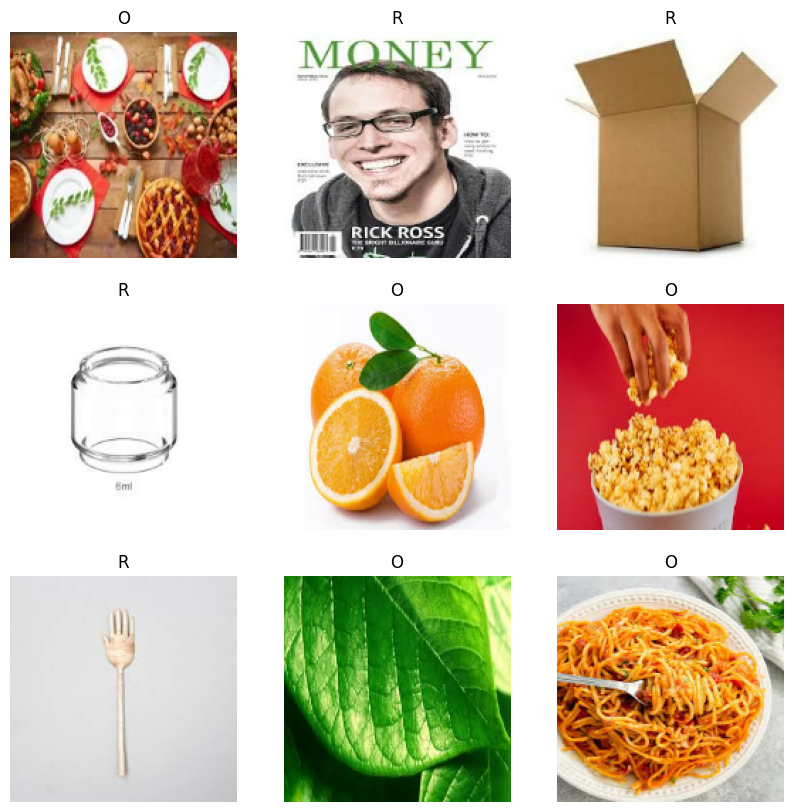

In [18]:
class_names = train_dataset.class_names

plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [19]:
val_batches = tf.data.experimental.cardinality(validation_dataset)
test_dataset = validation_dataset.take(val_batches // 5)
validation_dataset = validation_dataset.skip(val_batches // 5)

In [20]:
print('Number of validation batches: %d' % tf.data.experimental.cardinality(validation_dataset))
print('Number of test batches: %d' % tf.data.experimental.cardinality(test_dataset))

Number of validation batches: 64
Number of test batches: 15


In [21]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

In [22]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

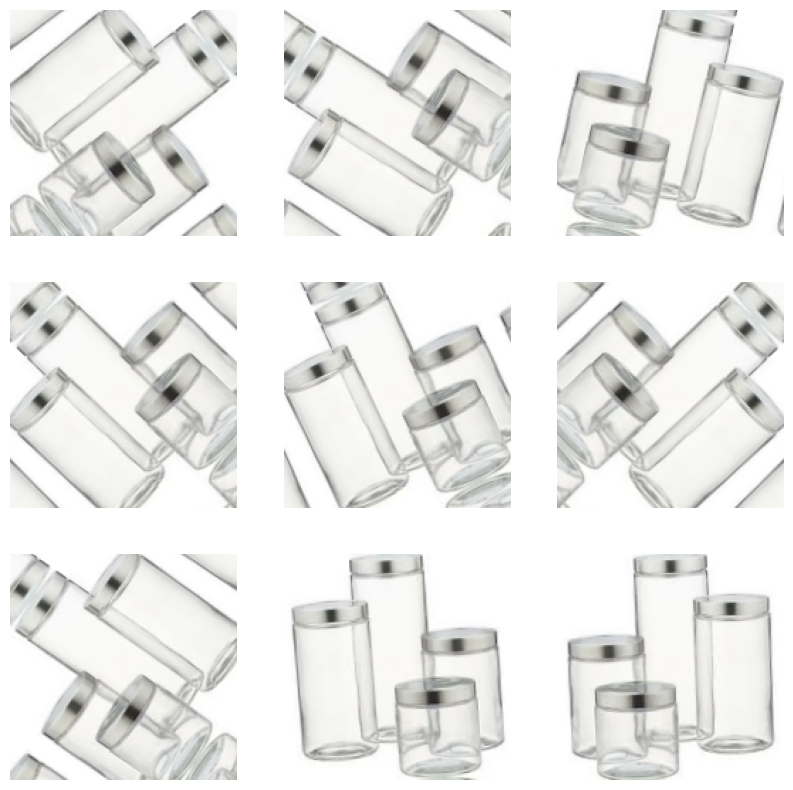

In [23]:
for image, _ in train_dataset.take(1):
  plt.figure(figsize=(10, 10))
  first_image = image[0]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255)
    plt.axis('off')

In [24]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
rescale = tf.keras.layers.Rescaling(1./127.5, offset= -1)

In [25]:
# Create the base model from the pre-trained model MobileNet V2
IMG_SHAPE = IMG_SIZE + (3,)
base_model = tf.keras.applications.MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [26]:
image_batch, label_batch = next(iter(train_dataset))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(32, 5, 5, 1280)


In [27]:
base_model.trainable = False

In [28]:
base_model.summary()

Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [29]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(32, 1280)


In [30]:
prediction_layer = tf.keras.layers.Dense(len(class_names))

In [31]:
batch_prediction = prediction_layer(feature_batch_average)
print(batch_prediction.shape)

(32, 2)


In [32]:
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = global_average_layer(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = prediction_layer(x)
model = tf.keras.Model(inputs, outputs)

In [33]:
base_learning_rate = 0.0001
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=base_learning_rate),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [34]:
model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [35]:
initial_epochs = 10
loss0, accuracy0 = model.evaluate(validation_dataset)
print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.4456 - loss: 1.0096
initial loss: 1.01
initial accuracy: 0.45


In [36]:
history = model.fit(train_dataset,
                    epochs=initial_epochs,
                    validation_data=validation_dataset)

Epoch 1/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.8054 - loss: 0.4386 - val_accuracy: 0.8834 - val_loss: 0.2798
Epoch 2/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 39s 39ms/step - accuracy: 0.8868 - loss: 0.2840 - val_accuracy: 0.9144 - val_loss: 0.2182
Epoch 3/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.9019 - loss: 0.2527 - val_accuracy: 0.9203 - val_loss: 0.2045
Epoch 4/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.9096 - loss: 0.2375 - val_accuracy: 0.9297 - val_loss: 0.1895
Epoch 5/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.9158 - loss: 0.2219 - val_accuracy: 0.9356 - val_loss: 0.1801
Epoch 6/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.9180 - loss: 0.2147 - val_accuracy: 0.9380 - val_loss: 0.1729
Epoch 7/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.9222 - loss: 0.2113 - val_accuracy: 0.9361 - val_loss: 0.1773
Epoch 8/10
706/706 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.9223 - loss: 0.2044 - 

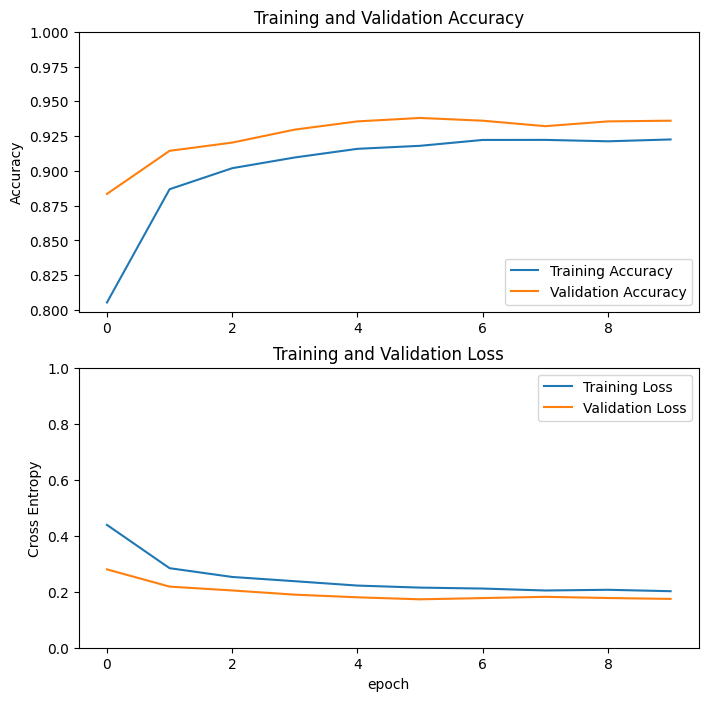

In [37]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [38]:
base_model.trainable = True

In [39]:
# Fine-tune from this layer onwards
fine_tune_at = 100

In [40]:
# Freeze all layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

In [41]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer = tf.keras.optimizers.RMSprop(learning_rate=base_learning_rate/10),
              metrics=['accuracy'])

In [42]:
model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 1,864,002 (7.11 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [43]:
len(model.trainable_variables)

56

In [44]:
fine_tune_epochs = 10
total_epochs =  initial_epochs + fine_tune_epochs

history_fine = model.fit(train_dataset,
                         epochs=total_epochs,
                         initial_epoch=history.epoch[-1],
                         validation_data=validation_dataset)

Epoch 10/20
706/706 ━━━━━━━━━━━━━━━━━━━━ 54s 61ms/step - accuracy: 0.9012 - loss: 0.2551 - val_accuracy: 0.9400 - val_loss: 0.1684
Epoch 11/20
706/706 ━━━━━━━━━━━━━━━━━━━━ 42s 59ms/step - accuracy: 0.9206 - loss: 0.2060 - val_accuracy: 0.9351 - val_loss: 0.1806
Epoch 12/20
706/706 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.9299 - loss: 0.1883 - val_accuracy: 0.9361 - val_loss: 0.1849
Epoch 13/20
706/706 ━━━━━━━━━━━━━━━━━━━━ 41s 59ms/step - accuracy: 0.9335 - loss: 0.1725 - val_accuracy: 0.9390 - val_loss: 0.1812
Epoch 14/20
706/706 ━━━━━━━━━━━━━━━━━━━━ 42s 59ms/step - accuracy: 0.9390 - loss: 0.1611 - val_accuracy: 0.9356 - val_loss: 0.1872
Epoch 15/20
706/706 ━━━━━━━━━━━━━━━━━━━━ 42s 59ms/step - accuracy: 0.9430 - loss: 0.1510 - val_accuracy: 0.9420 - val_loss: 0.1654
Epoch 16/20
706/706 ━━━━━━━━━━━━━━━━━━━━ 42s 59ms/step - accuracy: 0.9450 - loss: 0.1442 - val_accuracy: 0.9400 - val_loss: 0.1711
Epoch 17/20
706/706 ━━━━━━━━━━━━━━━━━━━━ 82s 59ms/step - accuracy: 0.9479 - loss: 0

In [45]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

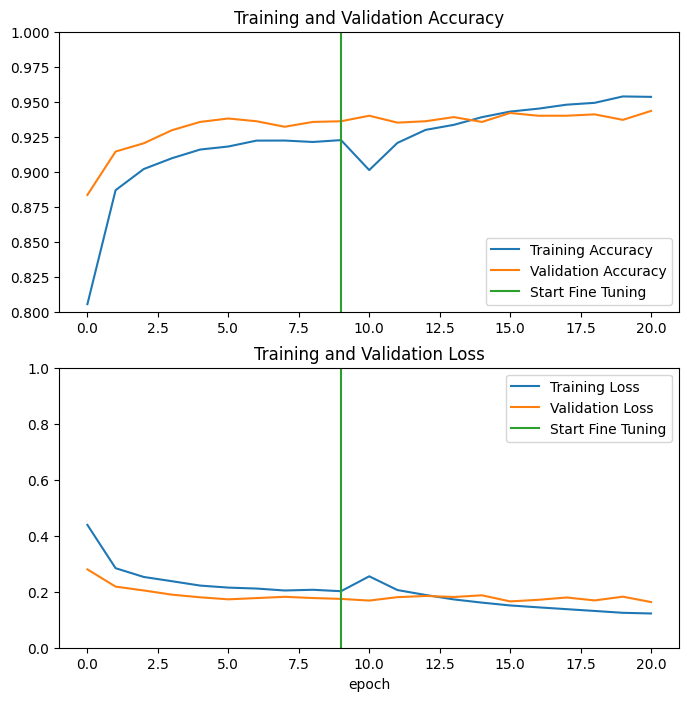

In [46]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([initial_epochs-1,initial_epochs-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs-1,initial_epochs-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [47]:
loss, accuracy = model.evaluate(test_dataset)
print('Test accuracy :', accuracy)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9458 - loss: 0.1294
Test accuracy : 0.9458333253860474


In [48]:
image_batch, label_batch = test_dataset.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch).flatten()

# Apply a sigmoid since our model returns logits
predictions = tf.nn.sigmoid(predictions)
predictions = tf.where(predictions < 0.5, 0, 1)

print('Predictions:\n', predictions.numpy())
print('Labels:\n', label_batch)

Predictions:
 [1 0 0 1 1 0 0 1 1 0 0 1 0 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 1 1 0 1 0 1
 0 1 0 1 0 1 0 0 1 0 1 0 1 1 0 1 0 1 0 0 0 1 0 1 0 1 0]
Labels:
 [0 1 0 1 0 1 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0]


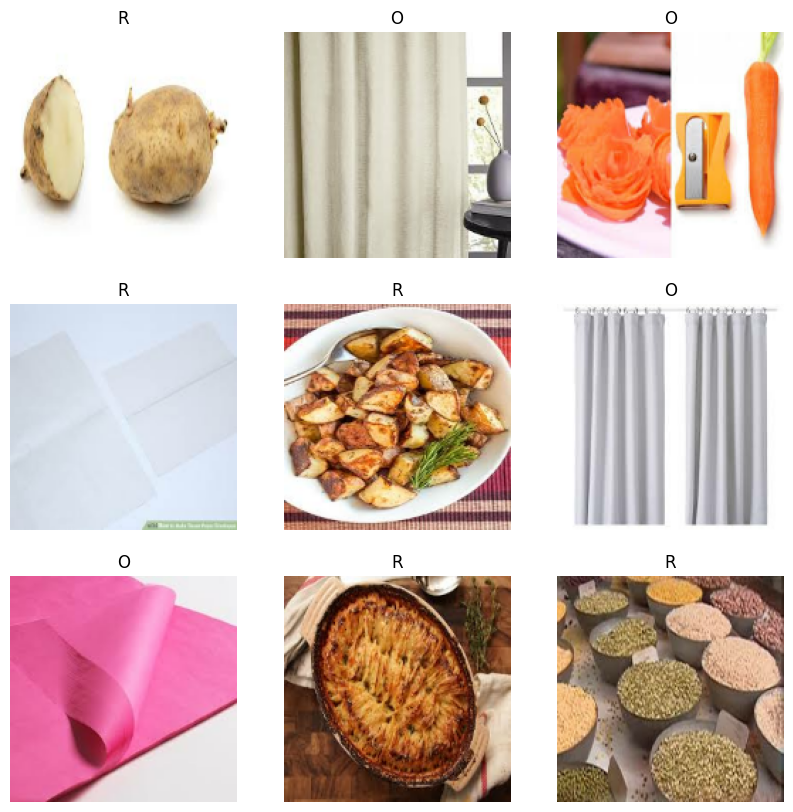

In [49]:
plt.figure(figsize=(10, 10))
for i in range(9):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].astype("uint8"))
  plt.title(class_names[predictions[i]])
  plt.axis("off")

To save the trained model, you can use `model.save()`. It's generally recommended to save Keras models with the `.keras` extension. The necessary directory structure will be created if it doesn't exist.

In [50]:
import os

# Define the export directory and filename with .keras extension
export_dir = 'saved_model/my_model.keras'

# Create the directory if it does not exist
os.makedirs(os.path.dirname(export_dir), exist_ok=True)

# Save the model
model.save(export_dir)

print(f"Model saved to: {export_dir}")

Model saved to: saved_model/my_model.keras


You can then load the model back using `tf.keras.models.load_model()`:

In [51]:
import tensorflow as tf

# Load the saved model
reloaded_model = tf.keras.models.load_model(export_dir)

print("Model reloaded successfully!")

Model reloaded successfully!


In [52]:
reload_result_batch = reloaded_model(image_batch)
print(tf.nn.sigmoid(reload_result_batch).numpy().flatten())

[9.52541292e-01 3.27408463e-02 1.96255803e-01 9.24368262e-01
 8.81588042e-01 4.66377765e-01 4.26815525e-02 9.75066602e-01
 9.96223688e-01 3.16521176e-03 3.01044006e-02 9.47570205e-01
 6.67212605e-02 9.96119857e-01 9.98390079e-01 2.54135369e-03
 9.34291363e-01 1.99481081e-02 8.90507936e-01 1.15754128e-01
 9.11312997e-01 5.14758751e-03 9.96185005e-01 5.41434344e-03
 9.91272509e-01 1.44287115e-02 9.68255997e-01 4.28572148e-02
 9.95388985e-01 6.79415986e-02 5.96667863e-02 9.17325139e-01
 9.90521431e-01 5.18635102e-03 9.93740976e-01 6.81482535e-03
 7.39460349e-01 3.33188713e-01 9.86477971e-01 2.61364579e-02
 9.68852878e-01 4.50651627e-03 9.98347521e-01 2.81090545e-03
 1.69912037e-02 9.52002823e-01 8.61624330e-02 9.01443303e-01
 2.11420640e-01 6.97574794e-01 9.99654055e-01 9.35111369e-04
 9.68061805e-01 4.58660871e-02 9.98767912e-01 1.43351848e-03
 5.11744618e-02 8.16756845e-01 9.64475214e-01 5.01443399e-03
 9.96605873e-01 9.15800862e-04 9.62491393e-01 6.17831899e-03]


To predict a new image, you need to load it, preprocess it to match the model's input expectations, and then use the `predict` method.

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Original Image Shape: (160, 160, 3)
Processed Image Shape for Prediction: (1, 160, 160, 3)
Predicted Class Probabilities: [0.58688045 0.41311955]
Predicted Class: O (Index: 0)
True Class: R (Index: 1)


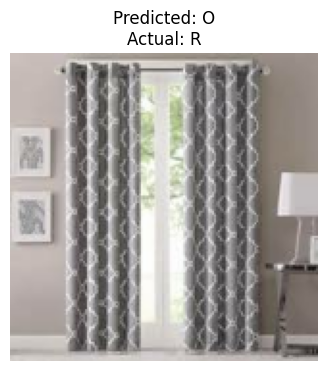

In [53]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Get one image and its true label from the test dataset for demonstration
# We'll treat this as a 'new' image that we want to predict
# test_dataset.take(1) will fetch the *next* image in the dataset
for image_batch_sample, label_batch_sample in test_dataset.take(1):
    sample_image = image_batch_sample[0]
    sample_true_label = label_batch_sample[0]
    break

# The model expects a batch of images, so expand dimensions for a single image
# The image is already preprocessed by the dataset pipeline (scaled to [0, 255])
# We just need to apply the MobileNetV2 specific preprocessing and batch dimension

# Apply MobileNetV2 preprocessing (rescales to [-1, 1])
processed_sample_image = preprocess_input(sample_image)

# Add the batch dimension
input_image_for_prediction = np.expand_dims(processed_sample_image, axis=0)

# Make a prediction using the reloaded model
predictions = reloaded_model.predict(input_image_for_prediction)

# Convert logits to probabilities (if using SparseCategoricalCrossentropy with from_logits=True)
probabilities = tf.nn.softmax(predictions[0])

# Get the predicted class index
predicted_class_index = np.argmax(probabilities)
predicted_class_name = class_names[predicted_class_index]

# Get the true class name
true_class_name = class_names[sample_true_label.numpy()]

print(f"Original Image Shape: {sample_image.shape}")
print(f"Processed Image Shape for Prediction: {input_image_for_prediction.shape}")
print(f"Predicted Class Probabilities: {probabilities.numpy()}")
print(f"Predicted Class: {predicted_class_name} (Index: {predicted_class_index})")
print(f"True Class: {true_class_name} (Index: {sample_true_label.numpy()})")

# Display the image with its prediction
plt.figure(figsize=(4, 4))
plt.imshow(sample_image.numpy().astype("uint8"))
plt.title(f"Predicted: {predicted_class_name}\nActual: {true_class_name}")
plt.axis("off")
plt.show()

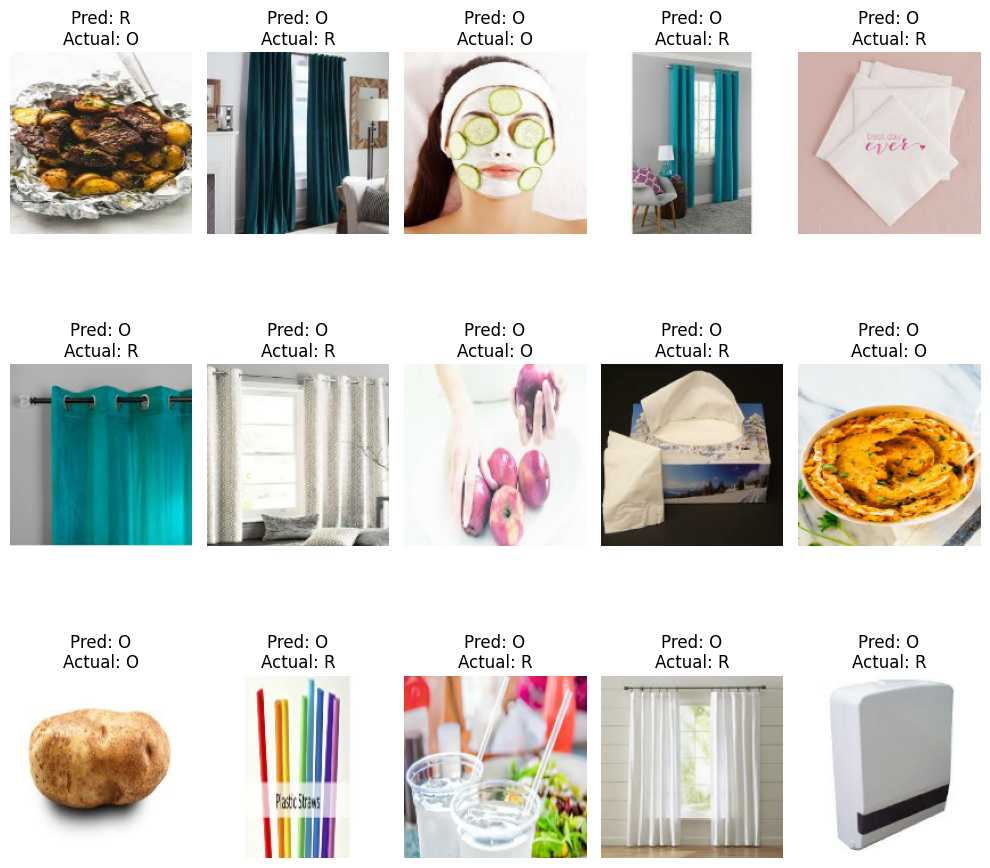

In [54]:
import random

# Get a batch of images and labels from the test dataset
for image_batch, label_batch in test_dataset.take(1):
    break

# Select 9 random indices from the batch
num_samples_to_display = 15
if len(image_batch) < num_samples_to_display:
    num_samples_to_display = len(image_batch)
    print(f"Only {num_samples_to_display} samples available in the batch.")

random_indices = random.sample(range(len(image_batch)), num_samples_to_display)

plt.figure(figsize=(10, 10))
for i, idx in enumerate(random_indices):
    sample_image = image_batch[idx]
    sample_true_label = label_batch[idx]

    # Preprocess the image for prediction
    processed_sample_image = preprocess_input(sample_image)
    input_image_for_prediction = np.expand_dims(processed_sample_image, axis=0)

    # Make a prediction
    predictions = reloaded_model.predict(input_image_for_prediction, verbose=0)
    probabilities = tf.nn.softmax(predictions[0])
    predicted_class_index = np.argmax(probabilities)

    predicted_class_name = class_names[predicted_class_index]
    true_class_name = class_names[sample_true_label.numpy()]

    ax = plt.subplot(3, 5, i + 1)
    plt.imshow(sample_image.numpy().astype("uint8"))
    plt.title(f"Pred: {predicted_class_name}\nActual: {true_class_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Here's how you can adapt the prediction code to load a new image from a specified path (which you would get from your hardware system). You'll need to replace the `img_path` with the actual path where your hardware system provides the images.

Simulating prediction for image at: temp_latest_trash_image.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted Class: O (Confidence: 65.13%)


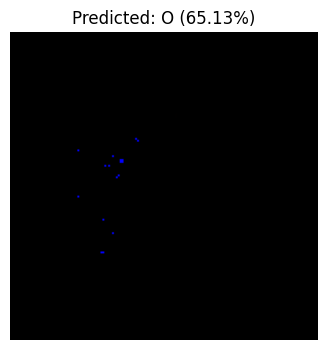

In [55]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Ensure reloaded_model, IMG_SIZE, preprocess_input, and class_names are defined
# from previous steps in your notebook.

def predict_new_image(img_path):
    try:
        # 1. Load the image from the specified path
        # Ensure the target_size matches what your model was trained with (IMG_SIZE)
        img = image.load_img(img_path, target_size=IMG_SIZE)
        img_array = image.img_to_array(img)

        # 2. Preprocess the image
        # The model expects a batch of images, so expand dimensions for a single image
        # Apply MobileNetV2 preprocessing (rescales to [-1, 1])
        processed_img_array = preprocess_input(img_array)

        # Add the batch dimension
        input_image_for_prediction = np.expand_dims(processed_img_array, axis=0)

        # 3. Make a prediction using the reloaded model
        predictions = reloaded_model.predict(input_image_for_prediction)

        # Convert logits to probabilities and get the predicted class
        probabilities = tf.nn.softmax(predictions[0])
        predicted_class_index = np.argmax(probabilities)
        predicted_class_name = class_names[predicted_class_index]
        confidence = probabilities[predicted_class_index].numpy() * 100

        # 4. Display the result
        print(f"Predicted Class: {predicted_class_name} (Confidence: {confidence:.2f}%)")

        plt.figure(figsize=(4, 4))
        plt.imshow(img_array.astype("uint8"))
        plt.title(f"Predicted: {predicted_class_name} ({confidence:.2f}%)")
        plt.axis("off")
        plt.show()

        return predicted_class_name, confidence

    except FileNotFoundError:
        print(f"Error: Image file not found at '{img_path}'. Please ensure the path is correct.")
        return None, None
    except Exception as e:
        print(f"An error occurred during prediction: {e}")
        return None, None

# --- How to use this function ---
# Replace 'path/to/your/latest_trash_image.jpg' with the actual path to the image
# that your hardware system provides.
# For demonstration, I'll use a random image from the test_dataset if you haven't provided one.

try:
    # Attempt to get a sample image path from the test_dataset for demonstration
    for img_batch_demo, _ in test_dataset.take(1):
        # For this demo, let's save one image temporarily to simulate a 'new' image file
        temp_img = tf.keras.preprocessing.image.array_to_img(img_batch_demo[0])
        demo_img_path = 'temp_latest_trash_image.jpg'
        temp_img.save(demo_img_path)
        break
except NameError:
    print("Test dataset not found. Please run previous cells to define 'test_dataset'.")
    demo_img_path = None

if demo_img_path:
    print(f"Simulating prediction for image at: {demo_img_path}")
    predict_new_image(demo_img_path)
else:
    print("No demo image path available. Please provide a valid path to an image file.")
    print("Example usage: predict_new_image('your_image_folder/my_trash_item.jpg')")


In [56]:
from google.colab import files
import os

# Tìm file .ipynb trong thư mục hiện tại
notebook_files = [f for f in os.listdir() if f.endswith('.ipynb')]

if notebook_files:
    # Lấy file .ipynb đầu tiên tìm được (thường là notebook hiện tại)
    notebook_name = notebook_files[0]
    print(f"Đang tải: {notebook_name}")
    files.download(notebook_name)
else:
    print("Không tìm thấy file .ipynb nào!")

Đang tải: Waste_Augumentation.ipynb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Deploy a Node Express App on Render

#Model Export and Serialization (DONE):
 Ensure the trained TensorFlow/Keras model is saved in a suitable format, like the .keras format, as demonstrated previously. This model will be used by our Python prediction service.
#Prepare Node.js and Express.js Environment:
 Set up your server with Node.js and npm. Install Express.js and any other necessary Node.js packages for handling HTTP requests and potentially image processing if needed on the Express.js side.
#Develop Python Prediction Microservice:
 Create a separate, lightweight Python script (e.g., using a minimal Flask app or FastAPI, or even a simple script that takes arguments and returns JSON) that loads the my_model.keras model and exposes a single HTTP endpoint for predictions. This service will handle the TensorFlow model inference.
#Develop Express.js API Gateway:
 Write an Express.js application that will serve as your main API endpoint. This application will receive incoming image prediction requests, potentially perform basic validation, and then forward these requests to the Python Prediction Microservice. It will then receive the prediction results from the Python service and return them to the client.
#Configure Inter-Service Communication:
 Detail how the Express.js API will communicate with the Python Prediction Microservice. This will typically involve the Express.js application making HTTP POST requests to the prediction service's endpoint, sending the image data, and parsing the JSON response.
#Containerization with Docker Compose:
 Package both the Express.js API and the Python Prediction Microservice into separate Docker containers. Create a docker-compose.yml file to define and orchestrate these two services, allowing them to run and communicate effectively in an isolated environment.
#Cloud Deployment (GCP with Docker Compose):
 Adapt the cloud deployment strategy to deploy your multi-container application to Google Cloud Platform. Options like Google Cloud Run (deploying each service independently) or Google Kubernetes Engine (GKE) are suitable for orchestrating multiple Docker containers in a production environment.
#Test the Full API Endpoint:
 Demonstrate how to test the end-to-end API, sending sample images to the Express.js API and verifying that it successfully uses the Python prediction service to return correct classification results. This can be done using client-side scripts, curl, or Postman.
#Hardware Integration (Conceptual):
 Explain how your hardware system would capture an image, format it appropriately, and send it to your deployed Express.js API endpoint for classification, focusing on the client-side interaction with the new API structure.
#Final Task:
 Summarize the successful deployment of the waste classification model as a cloud-based API endpoint using an Express.js gateway and a Python prediction microservice, ready for integration with the hardware system.
